In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [ ]:
BASE_PATH = "/content/drive/MyDrive/VisA_20220922/candle/Data"

TRAIN_GOOD = f"{BASE_PATH}/Images/Normal"
TEST_ANOM  = f"{BASE_PATH}/Images/Anomaly"
GT_PATH    = f"{BASE_PATH}/Masks/Anomaly"

print("Train normal:", len(os.listdir(TRAIN_GOOD)))
print("Test anomaly:", len(os.listdir(TEST_ANOM)))
print("GT masks:", len(os.listdir(GT_PATH)))


Train normal: 1000
Test anomaly: 100
GT masks: 100


In [ ]:
class VisaDataset(Dataset):
    def __init__(self, root_dir):
        self.image_paths = [
            os.path.join(root_dir, f)
            for f in os.listdir(root_dir)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ]

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        return self.transform(img)


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

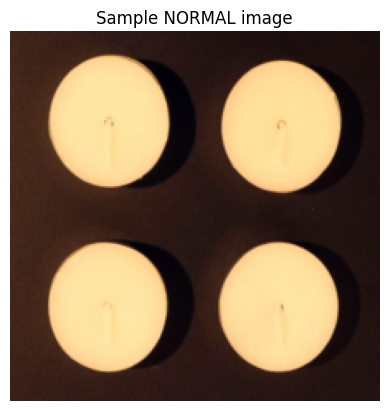

In [ ]:
dataset = VisaDataset(TRAIN_GOOD)

img = dataset[0]
img_vis = img.permute(1, 2, 0)
img_vis = (img_vis - img_vis.min()) / (img_vis.max() - img_vis.min())

plt.imshow(img_vis)
plt.title("Sample NORMAL image")
plt.axis("off")


In [ ]:
class FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()

        backbone = models.resnet50(pretrained=True)

        self.features = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool,
            backbone.layer1,
            backbone.layer2,
            backbone.layer3   # stop here (PatchCore standard)
        )

        for param in self.features.parameters():
            param.requires_grad = False

    def forward(self, x):
        return self.features(x)


In [ ]:
loader = DataLoader(dataset, batch_size=1, shuffle=True)

model = FeatureExtractor().to(device)
model.eval()

with torch.no_grad():
    sample = next(iter(loader)).to(device)
    features = model(sample)

print("Input shape:", sample.shape)
print("Feature map shape:", features.shape)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Input shape: torch.Size([1, 3, 224, 224])
Feature map shape: torch.Size([1, 1024, 14, 14])


In [ ]:
def extract_patches(feature_map):
    """
    feature_map: torch.Tensor [B, C, H, W]
    returns: torch.Tensor [B*H*W, C]
    """
    B, C, H, W = feature_map.shape
    patches = feature_map.permute(0, 2, 3, 1)  # [B, H, W, C]
    patches = patches.reshape(-1, C)           # [B*H*W, C]
    return patches


In [ ]:
from tqdm import tqdm

memory_bank = []

model.eval()

with torch.no_grad():
    for img in tqdm(loader):
        img = img.to(device)
        feature_map = model(img)
        patches = extract_patches(feature_map)
        memory_bank.append(patches.cpu())

memory_bank = torch.cat(memory_bank, dim=0)

print("Memory bank shape:", memory_bank.shape)


100%|██████████| 1000/1000 [05:46<00:00,  2.88it/s]


Memory bank shape: torch.Size([196000, 1024])


In [ ]:
print("Min:", memory_bank.min().item())
print("Max:", memory_bank.max().item())
print("Mean:", memory_bank.mean().item())


Min: 0.0
Max: 3.050447702407837
Mean: 0.03714340180158615


In [ ]:
import random

def random_coreset(memory_bank, coreset_size=5000):
    idx = torch.randperm(memory_bank.size(0))[:coreset_size]
    return memory_bank[idx]

coreset_size = 5000
memory_bank_coreset = random_coreset(memory_bank, coreset_size)

print("Coreset shape:", memory_bank_coreset.shape)


Coreset shape: torch.Size([5000, 1024])


In [ ]:
reduction_ratio = memory_bank_coreset.shape[0] / memory_bank.shape[0]
print(f"Memory reduced to {reduction_ratio:.2%} of original")


Memory reduced to 2.55% of original


In [ ]:
def euclidean_distance(a, b):
    # a: [N, D], b: [M, D]
    # returns: [N, M]
    return torch.cdist(a, b)


In [ ]:
def score_image(img, model, memory_bank):
    model.eval()

    with torch.no_grad():
        img = img.unsqueeze(0).to(device)
        feature_map = model(img)
        patches = extract_patches(feature_map).to(device)

        distances = euclidean_distance(patches, memory_bank.to(device))
        min_distances, _ = distances.min(dim=1)

        image_score = min_distances.max().item()
        patch_scores = min_distances.view(14, 14).cpu()

    return image_score, patch_scores


In [ ]:
test_dataset = VisaDataset(TRAIN_GOOD)
test_img = test_dataset[0]

score, heatmap = score_image(test_img, model, memory_bank_coreset)

print("Image anomaly score:", score)


Image anomaly score: 2.10205340385437


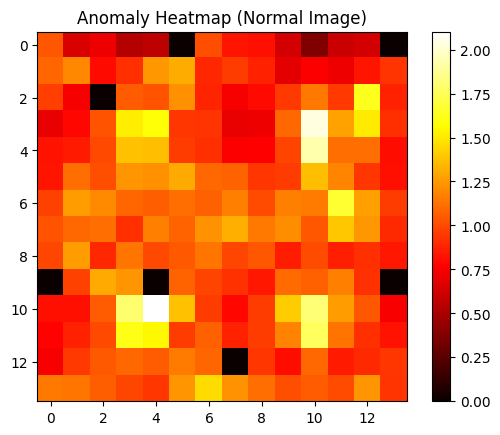

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(heatmap, cmap="hot")
plt.colorbar()
plt.title("Anomaly Heatmap (Normal Image)")
plt.show()


In [ ]:
anomaly_dataset = VisaDataset(TEST_ANOM)
anom_img = anomaly_dataset[0]

anom_score, anom_heatmap = score_image(anom_img, model, memory_bank_coreset)

print("Anomalous image score:", anom_score)


Anomalous image score: 2.7455546855926514


In [ ]:
import numpy as np
from tqdm import tqdm

def score_dataset(dataset, label):
    scores = []
    labels = []

    for img in tqdm(dataset):
        score, _ = score_image(img, model, memory_bank_coreset)
        scores.append(score)
        labels.append(label)

    return np.array(scores), np.array(labels)


In [ ]:
normal_dataset = VisaDataset(TRAIN_GOOD)
anomaly_dataset = VisaDataset(TEST_ANOM)

normal_scores, normal_labels = score_dataset(normal_dataset, label=0)
anomaly_scores, anomaly_labels = score_dataset(anomaly_dataset, label=1)

scores = np.concatenate([normal_scores, anomaly_scores])
labels = np.concatenate([normal_labels, anomaly_labels])

print("Normal scores:", normal_scores.shape)
print("Anomaly scores:", anomaly_scores.shape)


100%|██████████| 100/100 [00:37<00:00,  2.66it/s]

Normal scores: (1000,)
Anomaly scores: (100,)


In [ ]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

roc_auc = roc_auc_score(labels, scores)

precision, recall, _ = precision_recall_curve(labels, scores)
pr_auc = auc(recall, precision)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")


ROC-AUC: 0.8734
PR-AUC:  0.4932


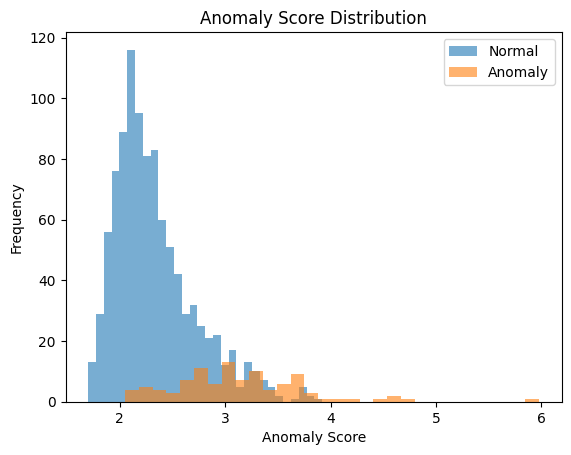

In [ ]:
import matplotlib.pyplot as plt

plt.hist(normal_scores, bins=30, alpha=0.6, label="Normal")
plt.hist(anomaly_scores, bins=30, alpha=0.6, label="Anomaly")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.legend()
plt.title("Anomaly Score Distribution")
plt.show()


In [ ]:
desired_recall = 0.95

precision, recall, thresholds = precision_recall_curve(labels, scores)

idx = np.where(recall >= desired_recall)[0][-1]
threshold = thresholds[idx]

print(f"Chosen threshold: {threshold:.3f}")
print(f"Recall at threshold: {recall[idx]:.3f}")
print(f"Precision at threshold: {precision[idx]:.3f}")


Chosen threshold: 2.201
Recall at threshold: 0.950
Precision at threshold: 0.147


In [ ]:
import torch.nn.functional as F

def upsample_heatmap(patch_scores, target_size=(224, 224)):
    """
    patch_scores: torch.Tensor [14, 14]
    returns: torch.Tensor [224, 224]
    """
    patch_scores = patch_scores.unsqueeze(0).unsqueeze(0)  # [1,1,14,14]
    heatmap = F.interpolate(
        patch_scores,
        size=target_size,
        mode="bilinear",
        align_corners=False
    )
    return heatmap.squeeze()


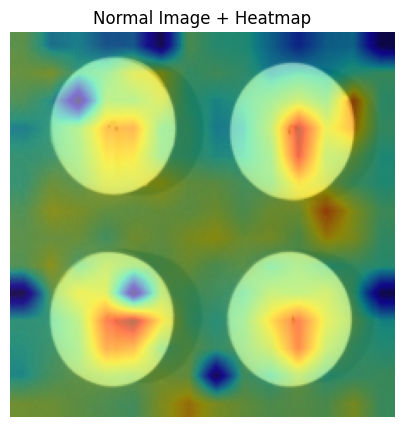

In [ ]:
import matplotlib.pyplot as plt

img = test_dataset[0]  # normal image
score, patch_map = score_image(img, model, memory_bank_coreset)

heatmap = upsample_heatmap(patch_map)

img_vis = img.permute(1, 2, 0)
img_vis = (img_vis - img_vis.min()) / (img_vis.max() - img_vis.min())

plt.figure(figsize=(5,5))
plt.imshow(img_vis)
plt.imshow(heatmap, cmap="jet", alpha=0.5)
plt.title("Normal Image + Heatmap")
plt.axis("off")
plt.show()


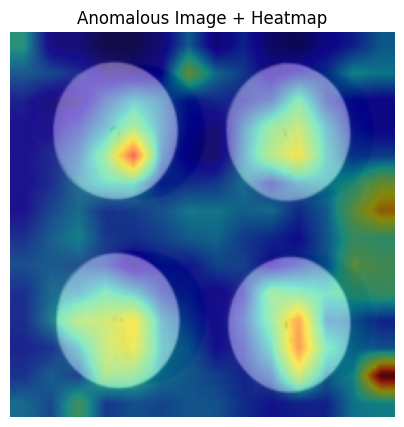

In [ ]:
anom_dataset = VisaDataset(TEST_ANOM)
anom_img = anom_dataset[0]

anom_score, anom_patch_map = score_image(anom_img, model, memory_bank_coreset)
anom_heatmap = upsample_heatmap(anom_patch_map)

anom_vis = anom_img.permute(1, 2, 0)
anom_vis = (anom_vis - anom_vis.min()) / (anom_vis.max() - anom_vis.min())

plt.figure(figsize=(5,5))
plt.imshow(anom_vis)
plt.imshow(anom_heatmap, cmap="jet", alpha=0.5)
plt.title("Anomalous Image + Heatmap")
plt.axis("off")
plt.show()


In [ ]:
def farthest_point_sampling(features, k):
    """
    features: torch.Tensor [N, D]
    k: number of points to sample
    """
    N = features.shape[0]
    selected = torch.zeros(k, dtype=torch.long)

    # start from a random point
    selected[0] = torch.randint(0, N, (1,))
    distances = torch.cdist(features[selected[0]].unsqueeze(0), features).squeeze()

    for i in range(1, k):
        selected[i] = torch.argmax(distances)
        new_dist = torch.cdist(features[selected[i]].unsqueeze(0), features).squeeze()
        distances = torch.minimum(distances, new_dist)

    return features[selected]


In [ ]:
# Subsample before FPS
subsample_size = 20000   # safe & fast
idx = torch.randperm(memory_bank.shape[0])[:subsample_size]
memory_sub = memory_bank[idx].to(device)

print("Subsample shape:", memory_sub.shape)


Subsample shape: torch.Size([20000, 1024])


In [ ]:
coreset_size = 5000

memory_bank_fps = farthest_point_sampling(
    memory_sub,
    coreset_size
).cpu()

print("FPS coreset shape:", memory_bank_fps.shape)


FPS coreset shape: torch.Size([5000, 1024])


In [ ]:
# score one normal & one anomaly using FPS coreset
score_n_fps, _ = score_image(test_dataset[0], model, memory_bank_fps)
score_a_fps, _ = score_image(anom_dataset[0], model, memory_bank_fps)

print("Normal score (FPS):", score_n_fps)
print("Anomaly score (FPS):", score_a_fps)


Normal score (FPS): 1.8029301166534424
Anomaly score (FPS): 2.8209261894226074


In [ ]:
# Pick low-scoring anomaly
low_idx = anomaly_scores.argsort()[0]
bad_img = anom_dataset[low_idx]

score, heatmap = score_image(bad_img, model, memory_bank_fps)


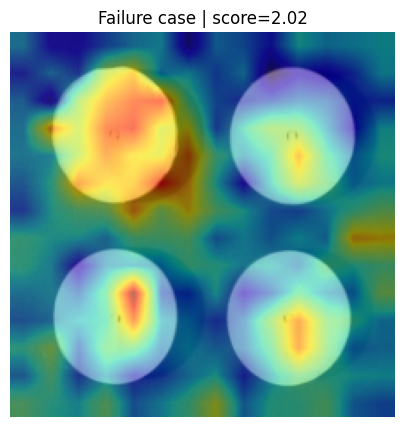

In [ ]:
heatmap_up = upsample_heatmap(heatmap)

img_vis = bad_img.permute(1, 2, 0)
img_vis = (img_vis - img_vis.min()) / (img_vis.max() - img_vis.min())

import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
plt.imshow(img_vis)
plt.imshow(heatmap_up, cmap="jet", alpha=0.5)
plt.title(f"Failure case | score={score:.2f}")
plt.axis("off")
plt.show()
